# Эксперименты: дообучение и оценка моделей суммаризации

1. Дообучаем FRED-T5-large (seq2seq) и Qwen2.5-3B (LoRA) на gazeta
2. Оцениваем все модели (zero-shot + fine-tuned)
3. Визуализируем результаты

In [1]:
import json
import os
import re
import time
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import load_from_disk
from IPython.display import display
from rouge_score import rouge_scorer
from tqdm.auto import tqdm
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (12, 5), "font.size": 11})

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

/home/gab1k/llm-hse/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: Tesla V100-PCIE-32GB


In [2]:
OFFLINE = "../offline_assets"
CHECKPOINTS = "../checkpoints"
DATASET_PATH = f"{OFFLINE}/gazeta_dataset"
RESULTS_DIR = "./results"
os.makedirs(CHECKPOINTS, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

QUICK_RUN = True
TRAIN_SAMPLES = 5000 if QUICK_RUN else None
VAL_SAMPLES = 100 if QUICK_RUN else 500
EVAL_SAMPLES = 100 if QUICK_RUN else 200

dataset = load_from_disk(DATASET_PATH)
if TRAIN_SAMPLES:
    dataset["train"] = dataset["train"].select(range(TRAIN_SAMPLES))
if VAL_SAMPLES:
    dataset["validation"] = dataset["validation"].select(range(VAL_SAMPLES))
print(f"Train: {len(dataset['train'])}, Val: {len(dataset['validation'])}, Test: {len(dataset['test'])}")

Train: 5000, Val: 100, Test: 6793


---
## 1. Дообучение Qwen2.5-3B-Instruct (LoRA)

In [3]:
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer, SFTConfig

CAUSAL_PROMPT_TEMPLATE = (
    "<|im_start|>system\n"
    "Ты — помощник для создания кратких резюме новостных статей на русском языке. "
    "Генерируй чёткое, информативное резюме без лишних слов.<|im_end|>\n"
    "<|im_start|>user\n"
    "Напиши резюме следующей статьи:\n\n{text}<|im_end|>\n"
    "<|im_start|>assistant\n"
    "{summary}<|im_end|>"
)

def format_prompt(example):
    text = example["text"]
    if len(text) > 3000:
        text = text[:3000]
    return CAUSAL_PROMPT_TEMPLATE.format(text=text, summary=example["summary"])

def train_qwen_lora(base_path, ckpt_path, label):
    print(f"\n{'='*60}")
    print(f"Обучаем {label}")

    tok = AutoTokenizer.from_pretrained(base_path, trust_remote_code=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        base_path, torch_dtype=torch.float16, device_map="auto", trust_remote_code=True
    )
    print(f"Параметров: {sum(p.numel() for p in model.parameters())/1e6:.0f}M")

    lora_config = LoraConfig(
        r=16, lora_alpha=32,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
        lora_dropout=0.05, bias="none", task_type=TaskType.CAUSAL_LM,
    )
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()

    sft_config = SFTConfig(
        output_dir=ckpt_path,
        num_train_epochs=1 if QUICK_RUN else 3,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=1 if QUICK_RUN else 4,
        gradient_checkpointing=True,
        learning_rate=3e-4,
        warmup_ratio=0.05,
        weight_decay=0.01,
        lr_scheduler_type="cosine",
        fp16=True,
        eval_strategy="epoch" if QUICK_RUN else "steps",
        eval_steps=None if QUICK_RUN else 200,
        save_strategy="epoch" if QUICK_RUN else "steps",
        save_steps=None if QUICK_RUN else 200,
        save_total_limit=2,
        load_best_model_at_end=True,
        logging_steps=5 if QUICK_RUN else 50,
        report_to="none",
        seed=42,
        optim="adamw_torch",
        max_length=1024,
        packing=True,
    )

    trainer = SFTTrainer(
        model=model,
        processing_class=tok,
        train_dataset=dataset["train"],
        eval_dataset=dataset["validation"],
        formatting_func=format_prompt,
        args=sft_config,
    )

    t0 = time.time()
    result = trainer.train()
    train_time = time.time() - t0

    trainer.save_model(ckpt_path)
    tok.save_pretrained(ckpt_path)

    metrics = result.metrics
    metrics["training_time_human"] = f"{int(train_time//3600)}h {int((train_time%3600)//60)}m"
    with open(f"{ckpt_path}/train_metrics.json", "w") as f:
        json.dump(metrics, f, indent=2, ensure_ascii=False)

    print(f"Готово за {metrics['training_time_human']}, Loss: {metrics.get('train_loss', 'N/A')}")

    del model, trainer
    torch.cuda.empty_cache()
    return metrics

In [4]:
# Qwen2.5-3B LoRA
qwen3b_metrics = train_qwen_lora(
    base_path=f"{OFFLINE}/Qwen__Qwen2.5-3B-Instruct",
    ckpt_path=f"{CHECKPOINTS}/qwen2.5-3b-lora",
    label="Qwen2.5-3B-Instruct + LoRA",
)


Обучаем Qwen2.5-3B-Instruct + LoRA


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 434/434 [00:01<00:00, 304.53it/s]


Параметров: 3086M


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[RANK 0] Padding-free training is enabled, but the attention implementation is not set to a supported flash attention variant. Padding-free training flattens batches into a single sequence, and only the following implementations are known to reliably support this: flash_attention_2, flash_attention_3, kernels-community/flash-attn2, kernels-community/flash-attn3, kernels-community/vllm-flash-attn3. Using other implementations may lead to unexpected behavior. To ensure compatibility, set `attn_implementation` in the model configuration to one of these supported options or verify that your attention mechanism can handle flattened sequences.
[RANK 0] You are using packing, but the attention implementation is not set to a supported flash attention variant. Packing gathers multiple samples into a single sequence, and only the following implementations are known to reliably support this: flash_attention_2, fla

trainable params: 29,933,568 || all params: 3,115,872,256 || trainable%: 0.9607


Packing eval dataset: 100%|██████████| 100/100 [00:00<00:00, 14695.20 examples/s]
[RANK 0] Detected kernel version 5.4.210, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Epoch,Training Loss,Validation Loss
1,1.469979,1.470957


Готово за 0h 58m, Loss: 1.5415578819274902


---
## 2. Дообучение Qwen2.5-7B-Instruct (LoRA)

In [5]:
try:
    qwen7b_metrics = train_qwen_lora(
        base_path=f"{OFFLINE}/Qwen__Qwen2.5-7B-Instruct",
        ckpt_path=f"{CHECKPOINTS}/qwen2.5-7b-lora",
        label="Qwen2.5-7B-Instruct + LoRA",
    )
except torch.cuda.OutOfMemoryError:
    print("OOM: не хватает VRAM для 7B, пропускаем")
    torch.cuda.empty_cache()


Обучаем Qwen2.5-7B-Instruct + LoRA


Loading weights: 100%|██████████| 339/339 [00:03<00:00, 97.45it/s] 


Параметров: 7616M


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[RANK 0] Padding-free training is enabled, but the attention implementation is not set to a supported flash attention variant. Padding-free training flattens batches into a single sequence, and only the following implementations are known to reliably support this: flash_attention_2, flash_attention_3, kernels-community/flash-attn2, kernels-community/flash-attn3, kernels-community/vllm-flash-attn3. Using other implementations may lead to unexpected behavior. To ensure compatibility, set `attn_implementation` in the model configuration to one of these supported options or verify that your attention mechanism can handle flattened sequences.
[RANK 0] You are using packing, but the attention implementation is not set to a supported flash attention variant. Packing gathers multiple samples into a single sequence, and only the following implementations are known to reliably support this: flash_attention_2, fla

trainable params: 40,370,176 || all params: 7,655,986,688 || trainable%: 0.5273


Packing eval dataset: 100%|██████████| 100/100 [00:00<00:00, 8539.24 examples/s]
[RANK 0] Detected kernel version 5.4.210, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Epoch,Training Loss,Validation Loss
1,1.378096,1.377509


Готово за 1h 35m, Loss: 1.4368973548889161


---
## 3. Оценка всех моделей

In [6]:
MODELS_EVAL = {
    "qwen2.5-3b-zeroshot": {
        "path": f"{OFFLINE}/Qwen__Qwen2.5-3B-Instruct",
        "type": "causal",
        "params_M": 3000,
    },
    "qwen2.5-3b-lora": {
        "path": f"{CHECKPOINTS}/qwen2.5-3b-lora",
        "base_path": f"{OFFLINE}/Qwen__Qwen2.5-3B-Instruct",
        "type": "causal_lora",
        "params_M": 3000,
    },
    "qwen2.5-7b-zeroshot": {
        "path": f"{OFFLINE}/Qwen__Qwen2.5-7B-Instruct",
        "type": "causal",
        "params_M": 7000,
    },
    "qwen2.5-7b-lora": {
        "path": f"{CHECKPOINTS}/qwen2.5-7b-lora",
        "base_path": f"{OFFLINE}/Qwen__Qwen2.5-7B-Instruct",
        "type": "causal_lora",
        "params_M": 7000,
    },
}

SEQ2SEQ_PREFIX = "Summarize: "
BATCH_SIZE = 8

LEN_CAUSAL = {
    "short":  {"max_new_tokens": 120, "temperature": 0.3, "do_sample": False},
    "medium": {"max_new_tokens": 220, "temperature": 0.3, "do_sample": False},
    "long":   {"max_new_tokens": 350, "temperature": 0.4, "do_sample": True},
}
CAUSAL_INSTR = {
    "short":  "Напиши КРАТКОЕ резюме статьи в 2-3 предложения.\n\n",
    "medium": "Напиши резюме статьи в 4-5 предложений.\n\n",
    "long":   "Напиши ПОДРОБНОЕ резюме статьи в 6-8 предложений.\n\n",
}

test_data = dataset["test"].select(range(EVAL_SAMPLES))
sources = list(test_data["text"])
references = list(test_data["summary"])
print(f"Eval samples: {len(sources)}")

Eval samples: 100


In [7]:
class _RuTokenizer:
    def tokenize(self, text):
        return re.findall(r'\w+', text.lower())


def tokenize_simple(text):
    return re.findall(r'\b\w+\b', text.lower())

def get_ngrams(tokens, n):
    return Counter(tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1))

def compression_ratio(src, summ):
    sw = len(src.split())
    return len(summ.split()) / sw if sw > 0 else 0.0

def novelty_score(src, summ, n=1):
    src_ng = set(get_ngrams(tokenize_simple(src), n).keys())
    sum_ng = list(get_ngrams(tokenize_simple(summ), n).keys())
    if not sum_ng:
        return 0.0
    return sum(1 for ng in sum_ng if ng not in src_ng) / len(sum_ng)


def build_causal_prompt(text, mode):
    instr = CAUSAL_INSTR[mode]
    if len(text) > 3500:
        text = text[:3500] + "..."
    return (
        f"<|im_start|>system\n"
        f"Ты — эксперт по созданию резюме новостных статей на русском языке. "
        f"Пиши чётко, информативно, без воды.<|im_end|>\n"
        f"<|im_start|>user\n{instr}Статья:\n{text}<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )


def gen_causal(model, tokenizer, texts, mode):
    params = LEN_CAUSAL[mode]
    eos_id = tokenizer.convert_tokens_to_ids("<|im_end|>")
    preds = []
    model.eval()
    for text in tqdm(texts, desc=f"causal [{mode}]", leave=False):
        prompt = build_causal_prompt(text, mode)
        inp = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1500).to(DEVICE)
        plen = inp["input_ids"].shape[1]
        with torch.no_grad():
            out = model.generate(
                **inp, no_repeat_ngram_size=3, repetition_penalty=1.1,
                eos_token_id=eos_id, pad_token_id=tokenizer.pad_token_id, **params,
            )
        s = tokenizer.decode(out[0][plen:], skip_special_tokens=True)
        preds.append(s.replace("<|im_end|>", "").strip())
    return preds


def compute_metrics(src_list, pred_list, ref_list):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], tokenizer=_RuTokenizer())
    agg = {k: [] for k in ['rouge1', 'rouge2', 'rougeL']}
    for ref, pred in zip(ref_list, pred_list):
        scores = scorer.score(ref, pred)
        for k in agg:
            agg[k].append(scores[k].fmeasure)
    r = {k: round(np.mean(v) * 100, 3) for k, v in agg.items()}

    comp = [compression_ratio(s, p) for s, p in zip(src_list, pred_list)]
    n1 = [novelty_score(s, p, 1) for s, p in zip(src_list, pred_list)]
    n2 = [novelty_score(s, p, 2) for s, p in zip(src_list, pred_list)]

    return {
        **r,
        "compression_ratio": round(np.mean(comp), 4),
        "novelty_1gram_%": round(np.mean(n1) * 100, 2),
        "novelty_2gram_%": round(np.mean(n2) * 100, 2),
        "avg_pred_words": round(np.mean([len(p.split()) for p in pred_list]), 1),
    }

In [8]:
all_results = {}
all_predictions = {}

for name, cfg in MODELS_EVAL.items():
    path = cfg["path"]
    mtype = cfg["type"]

    if not os.path.exists(path):
        print(f"Пропускаем {name}: {path} не найден")
        continue

    print(f"\n{'='*60}")
    print(f"{name} ({mtype}, {cfg['params_M']}M)")

    try:
        if mtype == "causal":
            tok = AutoTokenizer.from_pretrained(path, trust_remote_code=True)
            mdl = AutoModelForCausalLM.from_pretrained(path, torch_dtype=torch.float16, device_map="auto", trust_remote_code=True)
        elif mtype == "causal_lora":
            from peft import PeftModel, PeftConfig
            base_path = cfg["base_path"]
            tok = AutoTokenizer.from_pretrained(base_path, trust_remote_code=True)
            # Загружаем на CPU, мержим, потом на GPU — обходим баг accelerate
            base = AutoModelForCausalLM.from_pretrained(base_path, torch_dtype=torch.float16, trust_remote_code=True)
            mdl = PeftModel.from_pretrained(base, path)
            mdl = mdl.merge_and_unload()
            mdl = mdl.to(DEVICE)

        if tok.pad_token is None:
            tok.pad_token = tok.eos_token

        all_results[name] = {}
        all_predictions[name] = {}

        for mode in ["short", "medium", "long"]:
            preds = gen_causal(mdl, tok, sources, mode)
            m = compute_metrics(sources, preds, references)
            all_results[name][mode] = m
            all_predictions[name][mode] = preds
            print(f"  [{mode}] R1={m['rouge1']:.1f} R2={m['rouge2']:.1f} RL={m['rougeL']:.1f}")

        del mdl
        torch.cuda.empty_cache()

    except Exception as e:
        print(f"  Ошибка: {e}")
        import traceback; traceback.print_exc()


qwen2.5-3b-zeroshot (causal, 3000M)


causal [short]:   0%|          | 0/100 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  [short] R1=14.7 R2=1.3 RL=10.6


  [medium] R1=14.6 R2=0.9 RL=9.8


  [long] R1=12.4 R2=0.9 RL=8.4

qwen2.5-3b-lora (causal_lora, 3000M)


...

  [long] R1=13.2 R2=1.5 RL=9.1

qwen2.5-7b-lora (causal_lora, 7000M)


Loading weights: 100%|██████████| 339/339 [00:01<00:00, 172.80it/s]


  [short] R1=15.3 R2=2.1 RL=11.3


  [medium] R1=15.5 R2=2.0 RL=11.7


  [long] R1=14.3 R2=1.2 RL=10.2


In [9]:
from bert_score import score as bert_score_fn

bertscore_results = {}
for name in all_predictions:
    preds = all_predictions[name].get("medium", [])
    if not preds:
        continue
    print(f"BERTScore: {name}...")
    P, R, F1 = bert_score_fn(preds, references[:len(preds)], lang="ru", device=DEVICE, batch_size=32, verbose=False)
    bertscore_results[name] = {"P": round(P.mean().item()*100, 2), "R": round(R.mean().item()*100, 2), "F1": round(F1.mean().item()*100, 2)}
    print(f"  F1={bertscore_results[name]['F1']:.2f}")

display(pd.DataFrame(bertscore_results).T)

BERTScore: qwen2.5-3b-zeroshot...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3445.46it/s]
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  F1=67.91
BERTScore: qwen2.5-3b-lora...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2950.06it/s]
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  F1=69.10
BERTScore: qwen2.5-7b-zeroshot...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2690.39it/s]
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  F1=66.36
BERTScore: qwen2.5-7b-lora...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2627.49it/s]
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  F1=70.10


,P,R,F1
qwen2.5-3b-zeroshot,65.83,70.17,67.91
qwen2.5-3b-lora,70.52,67.80,69.10
qwen2.5-7b-zeroshot,63.77,69.28,66.36
qwen2.5-7b-lora,71.74,68.60,70.10


---
## 4. Таблицы и визуализация

In [10]:
rows = []
for name, modes in all_results.items():
    cfg = MODELS_EVAL.get(name, {})
    for mode, m in modes.items():
        rows.append({
            "Model": name, "Mode": mode, "Params (M)": cfg.get("params_M", "-"),
            "ROUGE-1": m["rouge1"], "ROUGE-2": m["rouge2"], "ROUGE-L": m["rougeL"],
            "Comp.Ratio": m["compression_ratio"],
            "Nov-1%": m["novelty_1gram_%"], "Avg words": m["avg_pred_words"],
        })
display(pd.DataFrame(rows))

,Model,Mode,Params (M),ROUGE-1,ROUGE-2,ROUGE-L,Comp.Ratio,Nov-1%,Avg words
0,qwen2.5-3b-zeroshot,short,3000,14.699,1.322,10.632,0.0794,68.69,45.1
1,qwen2.5-3b-zeroshot,medium,3000,14.612,0.930,9.841,0.1366,71.09,77.4
2,qwen2.5-3b-zeroshot,long,3000,12.404,0.889,8.436,0.1965,75.09,111.3
3,qwen2.5-3b-lora,short,3000,13.482,1.101,9.747,0.0525,67.01,29.6
4,qwen2.5-3b-lora,medium,3000,13.263,1.276,9.730,0.0523,67.10,29.5
5,qwen2.5-3b-lora,long,3000,12.878,1.139,9.680,0.0681,67.93,38.3
6,qwen2.5-7b-zeroshot,short,7000,13.209,1.561,9.578,0.0704,71.48,40.4
7,qwen2.5-7b-zeroshot,medium,7000,13.841,1.663,9.693,0.1157,72.59,66.3
8,qwen2.5-7b-zeroshot,long,7000,13.230,1.528,9.134,0.1659,73.76,95.4
9,qwen2.5-7b-lora,short,7000,15.341,2.051,11.348,0.0492,63.40,28.1


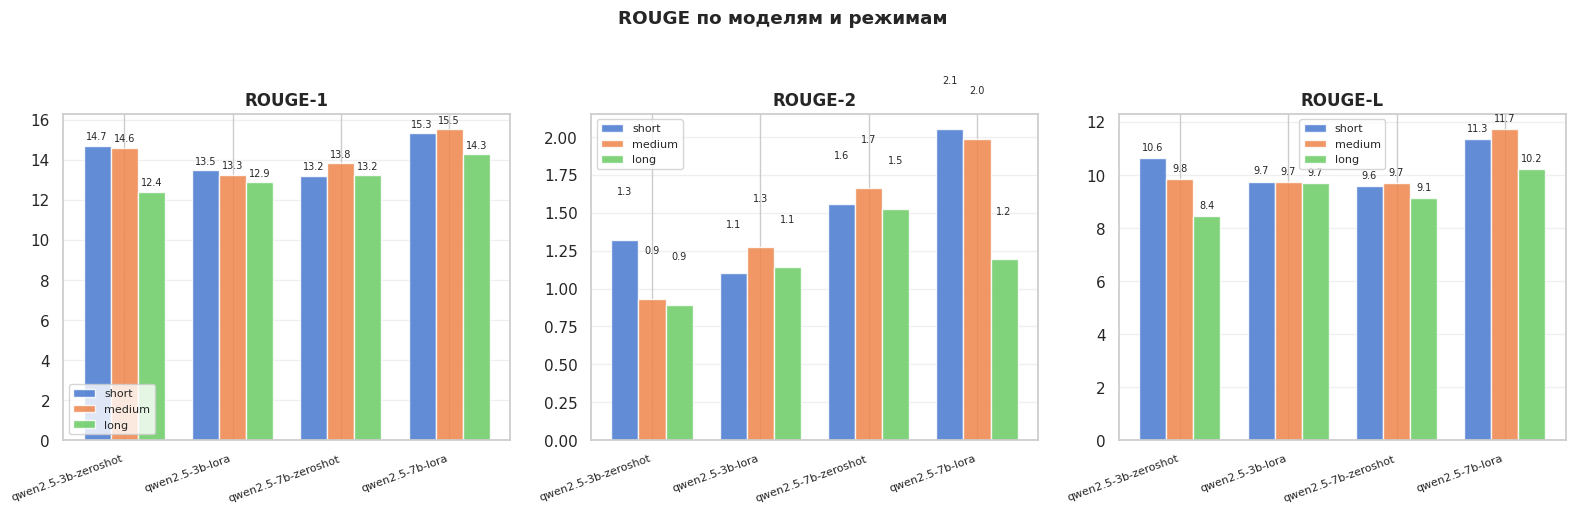

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, title in zip(axes, ["rouge1", "rouge2", "rougeL"], ["ROUGE-1", "ROUGE-2", "ROUGE-L"]):
    names = list(all_results.keys())
    x = np.arange(len(names))
    w = 0.25
    for j, mode in enumerate(["short", "medium", "long"]):
        vals = [all_results[n].get(mode, {}).get(metric, 0) for n in names]
        bars = ax.bar(x + j*w, vals, w, label=mode, alpha=0.85)
        for b, v in zip(bars, vals):
            if v: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f"{v:.1f}", ha="center", fontsize=7)
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(x+w); ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.suptitle("ROUGE по моделям и режимам", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/rouge_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

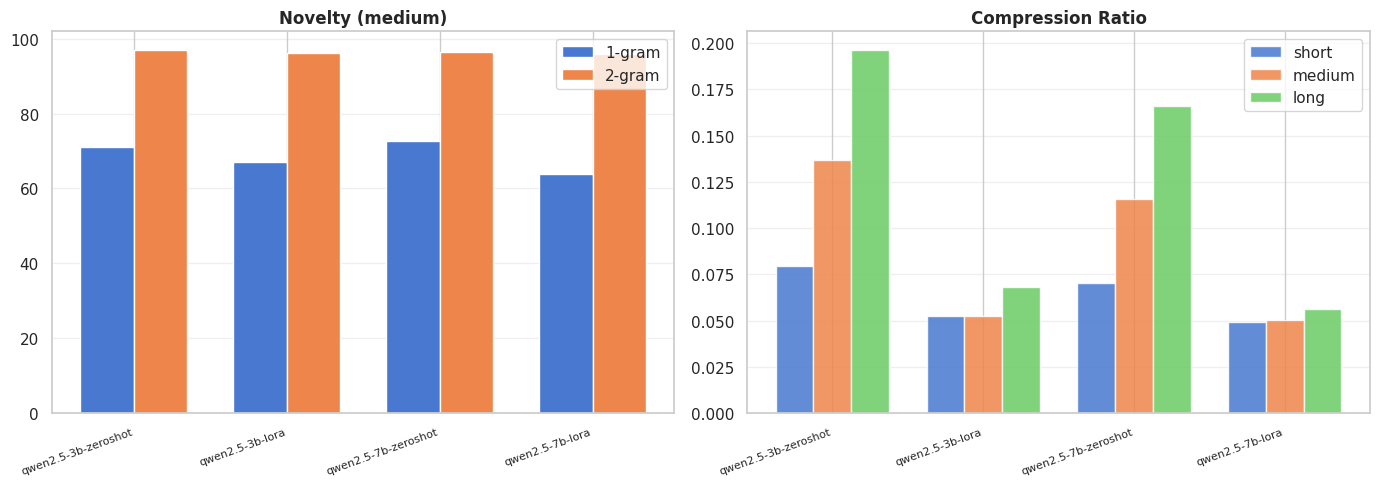

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names = list(all_results.keys())
x = np.arange(len(names))

n1 = [all_results[n].get("medium",{}).get("novelty_1gram_%",0) for n in names]
n2 = [all_results[n].get("medium",{}).get("novelty_2gram_%",0) for n in names]
w=0.35
axes[0].bar(x-w/2, n1, w, label="1-gram"); axes[0].bar(x+w/2, n2, w, label="2-gram")
axes[0].set_title("Novelty (medium)", fontweight="bold")
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=20, ha="right", fontsize=8)
axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)

w=0.25
for j, mode in enumerate(["short","medium","long"]):
    vals = [all_results[n].get(mode,{}).get("compression_ratio",0) for n in names]
    axes[1].bar(x+j*w, vals, w, label=mode, alpha=0.85)
axes[1].set_title("Compression Ratio", fontweight="bold")
axes[1].set_xticks(x+w); axes[1].set_xticklabels(names, rotation=20, ha="right", fontsize=8)
axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/novelty_compression.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
summary_rows = []
for name, modes in all_results.items():
    cfg = MODELS_EVAL.get(name, {})
    med = modes.get("medium", {})
    bs = bertscore_results.get(name, {})

    train_time = "-"
    tp = os.path.join(cfg.get("path", ""), "train_metrics.json")
    if os.path.exists(tp):
        with open(tp) as f:
            train_time = json.load(f).get("training_time_human", "-")

    summary_rows.append({
        "Модель": name,
        "Параметры (M)": cfg.get("params_M", "-"),
        "Время обучения": train_time,
        "ROUGE-1": med.get("rouge1", "-"),
        "ROUGE-2": med.get("rouge2", "-"),
        "ROUGE-L": med.get("rougeL", "-"),
        "BERTScore F1": bs.get("F1", "-"),
        "Nov-1%": med.get("novelty_1gram_%", "-"),
        "Comp.Ratio": med.get("compression_ratio", "-"),
    })

final_df = pd.DataFrame(summary_rows)
display(final_df)
final_df.to_csv(f"{RESULTS_DIR}/final_comparison.csv", index=False)
print(f"Сохранено в {RESULTS_DIR}/final_comparison.csv")

,Модель,Параметры (M),Время обучения,ROUGE-1,ROUGE-2,ROUGE-L,BERTScore F1,Nov-1%,Comp.Ratio
0,qwen2.5-3b-zeroshot,3000,-,14.612,0.930,9.841,67.91,71.09,0.1366
1,qwen2.5-3b-lora,3000,0h 58m,13.263,1.276,9.730,69.10,67.10,0.0523
2,qwen2.5-7b-zeroshot,7000,-,13.841,1.663,9.693,66.36,72.59,0.1157
3,qwen2.5-7b-lora,7000,1h 35m,15.531,1.990,11.723,70.10,63.86,0.0501


Сохранено в ./results/final_comparison.csv


In [14]:
for idx in [0, 5, 20]:
    if idx >= len(sources): continue
    print(f"\n{'='*70}")
    print(f"ПРИМЕР #{idx}")
    print(f"ТЕКСТ: {sources[idx][:300]}...")
    print(f"ЭТАЛОН: {references[idx]}")
    for name in all_predictions:
        p = all_predictions[name].get("medium", [])
        if idx < len(p):
            print(f"\n{name}: {p[idx]}")


ПРИМЕР #0
ТЕКСТ: На этих выходных в Берлине прошли крупные акции протеста против введенных для борьбы с коронавирусом ограничений. Демонстранты скандировали «Путин!» По словам депутата городской палаты представителей Гуннара Линдеманна («Альтернатива для Германии»), люди выкрикивали фамилию российского президента из...
ЭТАЛОН: Протестующие против антикоронавирусных мер немцы скандировали имя российского президента, потому что уважают его. Такое мнение выразил депутат городской палаты представителей Гуннар Линдеманн. На этих выходных в Берлине прошли крупные акции протеста. Манифестанты требовали отменить ношение масок и отказаться от соблюдения безопасного расстояния в 1,5 м друг от друга.

qwen2.5-3b-zeroshot: В Берлинские улицы вышли сотни тысяч людей на акции против коронаконтролей. Среди них были и те, кто скандировал имя Владимира Путина в знак ув效rence. Политик Гуннкар Линдemann объяснил это желанием привлечения внимания к проблемам в ГД. Акции проходили мирно, однако в парлAMEN